# Exploração dos dados e modelo de score (PySpark)

Análise exploratória da camada **Gold** e avaliação do modelo `pyspark.ml` que estima o `SCORE` de crédito.
As agregações rodam no Spark e só o resultado (pequeno) é convertido para pandas para plotar.
Todo o processamento vem do pacote `credit_pipeline`, o mesmo código que roda na CLI, no Airflow e no CI.
Para reproduzir: `make install && make run-local`, depois execute este notebook.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import functions as F

from credit_pipeline import ml
from credit_pipeline.config import Paths, gold
from credit_pipeline.gold import CATEGORIAS_RENDA, FAIXAS_ETARIAS
from credit_pipeline.io import read_layer
from credit_pipeline.spark import get_spark

sns.set_theme(style="whitegrid", palette="crest")
pd.set_option("display.float_format", "{:,.2f}".format)

spark = get_spark("exploracao")
paths = Paths.from_env()
df = read_layer(paths, gold("dados_gold")).cache()
print(f"{df.count():,} clientes | {len(df.columns)} colunas")

10,476 clientes | 24 colunas


## 1. Visão geral

In [2]:
colunas = ["IDADE", "RENDA_TOTAL", "SCORE", "QT_IMOVEIS", "VL_IMOVEIS", "QT_CARROS", "TEMPO_ULTIMO_EMPREGO_MESES"]
resumo = df.select(colunas).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").toPandas()
resumo.set_index("summary").astype(float).T

summary,count,mean,stddev,min,25%,50%,75%,max
IDADE,"10,476.00",41.05,13.88,19.00,28.00,42.00,53.00,65.00
RENDA_TOTAL,"10,476.00","8,927.77","6,242.97","1,800.00","3,900.00","8,500.00","11,500.00","24,400.00"
SCORE,"10,476.00",50.74,27.22,12.00,28.00,45.00,72.00,98.00
QT_IMOVEIS,"10,476.00",0.85,0.96,0.00,0.00,1.00,1.00,3.00
VL_IMOVEIS,"10,476.00","238,453.61","265,843.93",0.00,0.00,"185,000.00","370,000.00","900,000.00"
QT_CARROS,"10,476.00",0.94,0.81,0.00,0.00,1.00,2.00,2.00
TEMPO_ULTIMO_EMPREGO_MESES,"10,476.00",43.07,40.85,8.00,14.00,22.00,75.00,150.00


## 2. Distribuição do score

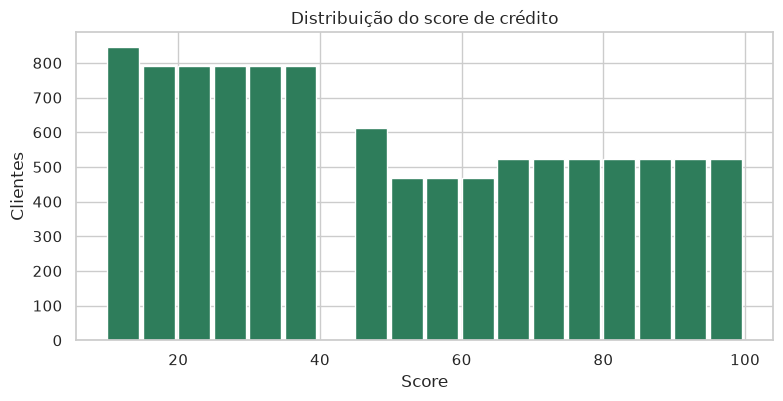

In [3]:
histograma = (
    df.groupBy((F.floor(F.col("SCORE") / 5) * 5).alias("faixa"))
    .count()
    .orderBy("faixa")
    .toPandas()
)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(histograma["faixa"], histograma["count"], width=4.5, align="edge", color="#2E7D5B")
ax.set(title="Distribuição do score de crédito", xlabel="Score", ylabel="Clientes")
plt.show()

## 3. Score por faixa etária e categoria de renda

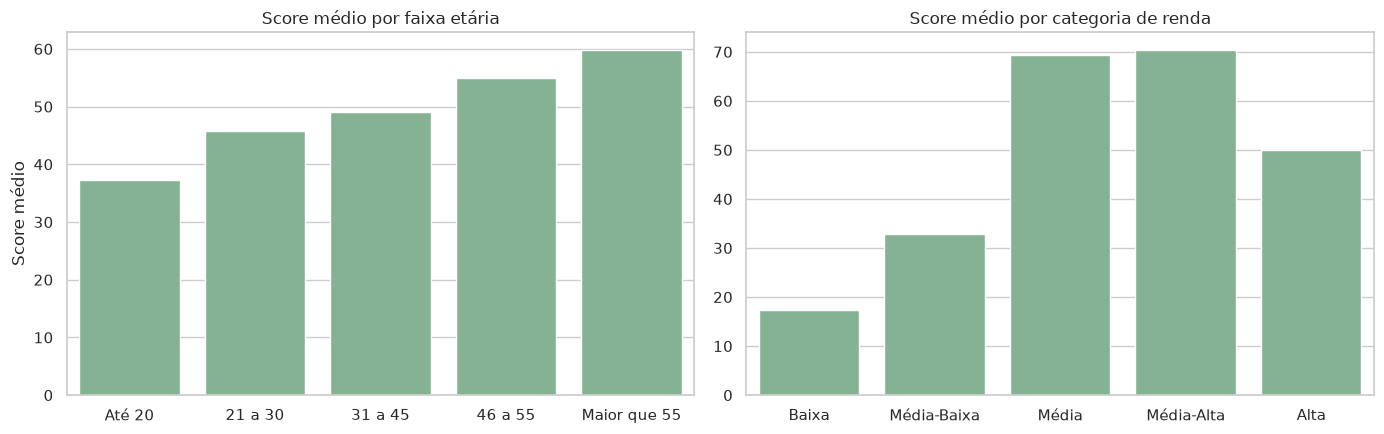

In [4]:
por_faixa = df.groupBy("FAIXA_ETARIA").agg(F.avg("SCORE").alias("score_medio")).toPandas()
por_renda = df.groupBy("CATEGORIA_RENDA").agg(F.avg("SCORE").alias("score_medio")).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=por_faixa, x="FAIXA_ETARIA", y="score_medio", order=FAIXAS_ETARIAS, ax=axes[0])
axes[0].set(title="Score médio por faixa etária", xlabel="", ylabel="Score médio")
sns.barplot(data=por_renda, x="CATEGORIA_RENDA", y="score_medio", order=CATEGORIAS_RENDA, ax=axes[1])
axes[1].set(title="Score médio por categoria de renda", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

## 4. Correlação com o score

In [5]:
numericas = ["IDADE", "QT_FILHOS", "QT_IMOVEIS", "VL_IMOVEIS", "OUTRA_RENDA_VALOR", "TEMPO_ULTIMO_EMPREGO_MESES",
             "ULTIMO_SALARIO", "QT_CARROS", "VALOR_TABELA_CARROS", "RENDA_TOTAL"]
# Todas as correlações em uma única agregação, em vez de um df.stat.corr por coluna.
linha = df.agg(*[F.corr(c, "SCORE").alias(c) for c in numericas]).first().asDict()
pd.Series(linha).sort_values(ascending=False).to_frame("correlacao_com_score")

,correlacao_com_score
TEMPO_ULTIMO_EMPREGO_MESES,0.76
VL_IMOVEIS,0.65
RENDA_TOTAL,0.64
ULTIMO_SALARIO,0.60
QT_IMOVEIS,0.58
OUTRA_RENDA_VALOR,0.38
VALOR_TABELA_CARROS,0.35
QT_FILHOS,0.34
IDADE,0.22
QT_CARROS,0.06


## 5. Patrimônio versus score

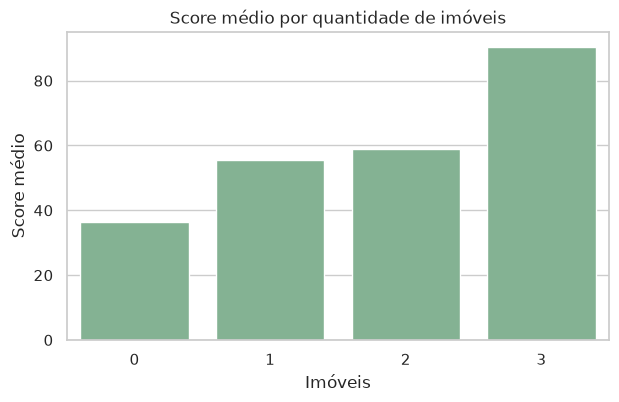

In [6]:
patrimonio = (
    df.groupBy("QT_IMOVEIS")
    .agg(F.avg("SCORE").alias("score_medio"), F.count("*").alias("clientes"))
    .orderBy("QT_IMOVEIS")
    .toPandas()
)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=patrimonio, x="QT_IMOVEIS", y="score_medio", ax=ax)
ax.set(title="Score médio por quantidade de imóveis", xlabel="Imóveis", ylabel="Score médio")
plt.show()

## 6. Modelo de regressão para o score

Pipeline `pyspark.ml`: `StringIndexer` + `OneHotEncoder` nas categóricas, `StandardScaler` nas numéricas e
`LinearRegression`, avaliado em 30% dos dados separados para teste. A comparação com um baseline que sempre
prevê a média mostra quanto o modelo realmente agrega.

`RENDA_TOTAL` e `OUTRA_RENDA` ficam de fora porque são combinações exatas de outras colunas. Com elas o modelo
passa a usar pares de variáveis que se cancelam, o que torna os coeficientes enganosos.

In [7]:
model, metrics = ml.train(df)
pd.DataFrame({"modelo": metrics["modelo"], "baseline (média)": metrics["baseline_media"]})

,modelo,baseline (média)
r2,0.92,-0.00
mae,6.35,23.61
rmse,7.57,27.02


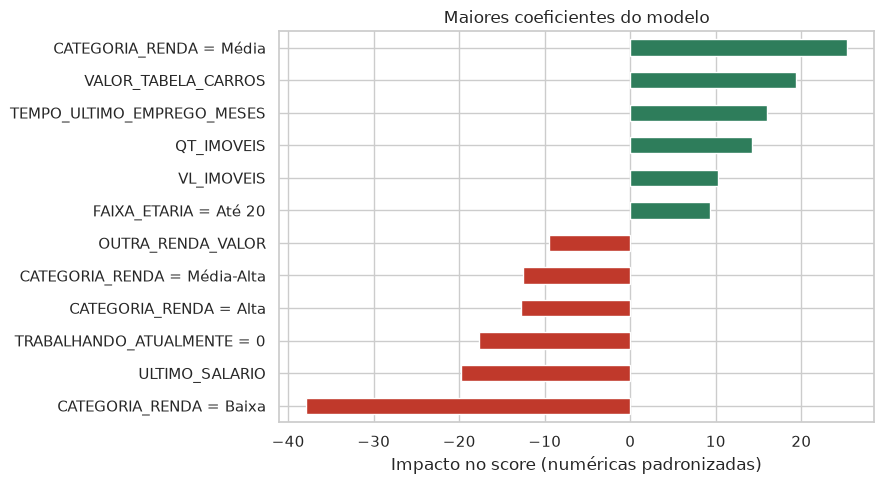

In [8]:
# Nomes das features a partir dos metadados do vetor montado pelo VectorAssembler.
amostra = model.transform(ml.prepare(df).limit(1))
atributos = amostra.schema["features"].metadata["ml_attr"]["attrs"]
nomes = {a["idx"]: a["name"] for grupo in atributos.values() for a in grupo}
coeficientes = pd.Series(model.stages[-1].coefficients.toArray(), index=[nomes[i] for i in range(len(nomes))])
# O StandardScaler não propaga os nomes das numéricas, só a posição: recupera pela ordem de ml.NUMERIC_FEATURES.
coeficientes.index = [
    ml.NUMERIC_FEATURES[int(n.rsplit("_", 1)[1])] if n.startswith("numericas_padronizadas_") else n.replace("_ohe_", " = ")
    for n in coeficientes.index
]
top = coeficientes.reindex(coeficientes.abs().sort_values(ascending=False).index).head(12).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
top.plot.barh(ax=ax, color=["#C0392B" if v < 0 else "#2E7D5B" for v in top])
ax.set(title="Maiores coeficientes do modelo", xlabel="Impacto no score (numéricas padronizadas)")
plt.tight_layout()
plt.show()

## 7. Conclusões

- **Tempo no último emprego é o sinal numérico mais forte** do score (correlação de 0,76), seguido de valor dos imóveis e renda total.
- **A relação com renda não é linear**: clientes de renda *Média* e *Média-Alta* têm score maior que os de renda *Alta*. Por isso a `CATEGORIA_RENDA` criada na camada Gold aparece entre os maiores coeficientes do modelo.
- **O score cresce com a idade** de forma consistente em todas as faixas.
- O modelo explica **92% da variância** do score no conjunto de teste (MAE de ~6 pontos numa escala de 0 a 100), contra 0% do baseline, resultado equivalente ao da versão pandas/scikit-learn na branch `main`.
- Os coeficientes das categóricas são relativos à categoria de referência removida pelo `OneHotEncoder` (a última em ordem alfabética), então devem ser lidos como diferenças em relação a ela.

**Ressalva:** a base é didática e tem muitos perfis repetidos, então essas métricas não se transfeririam diretamente para dados reais. Próximos passos seriam validação cruzada (`CrossValidator`), um modelo não linear (`GBTRegressor`) e monitoramento de drift.